In [1]:
import pandas as pd

In [2]:
df1=pd.read_csv('data/final/shap_values_all_wsci_stratisfy.csv')
df1=df1[[ 'PID','lon', 'lat','WSCI_group', 'shap_Raos_Q', 'shap_Functional_Evenness',
                 'shap_Species Richness', 'shap_Shannon Diversity', 'shap_Simpson\'s Index', 'shap_Species Richness']]

In [3]:
fd_df = pd.read_csv('data/final/final_dataset.csv')


# fd_df=fd_df[['PID', 'WSCI','Annual Temp', 'Annual Precipitation', 'Precipitation Seasonality',]]
# fd_df["WSCI_group"] = pd.qcut(fd_df["WSCI"], q=6, labels=["Q1", "Q2", "Q3", "Q4", "Q5", "Q6"])

In [ ]:
PID_df= pd.read_csv('data/lookup/PID_location_all.csv')
fd_df=fd_df.merge(PID_df[['PID', 'biome', 'lon', 'lat']], on='PID', how='left')


In [ ]:
# Identify the feature columns (everything except PID)
feature_cols = ['shap_Raos_Q', 'shap_Functional_Evenness',
                 'shap_Species Richness',]

# Find the column name with the largest SHAP value for each row
top_feature_df = pd.DataFrame({
    'PID': df1['PID'],
    'top_feature': df1[feature_cols].idxmax(axis=1),
    'WSCI_group': df1['WSCI_group'], 
    'lon': df1['lon'],
    'lat': df1['lat']
})


In [ ]:
df2=top_feature_df.merge(fd_df, on='PID', how='left')

In [ ]:
df2

,PID,top_feature,WSCI_group,lon_x,lat_x,Raos_Q,Functional_Evenness,Functional_Richness,Species Richness,Shannon Diversity,...,Elevation,Slope,Depth to Bedrock,Northness,transformed npp,treecover2000,pet_std,biome,lon_y,lat_y
0,0_42_109_1113_1,shap_Raos_Q,Q1,-77.07423,40.74303,3.693965,0.452516,NaN,5,1.242956,...,565.5,7.263684,197.635162,0.132662,1.230337,83,48.265215,Temperate broadleaf forests,-77.07423,40.74303
1,0_42_109_1113_1,shap_Raos_Q,Q1,-77.07423,40.74303,3.693965,0.452516,NaN,5,1.242956,...,565.5,7.263684,197.635162,0.132662,1.230337,83,48.265215,Temperate broadleaf forests,-77.07423,40.74303
2,0_42_109_1113_1,shap_Raos_Q,Q1,-77.07423,40.74303,3.693965,0.452516,NaN,5,1.242956,...,565.5,7.263684,197.635162,0.132662,1.230337,83,48.265215,Temperate broadleaf forests,-77.07423,40.74303
3,0_42_109_1113_1,shap_Raos_Q,Q1,-77.07423,40.74303,3.693965,0.452516,NaN,5,1.242956,...,565.5,7.263684,197.635162,0.132662,1.230337,83,48.265215,Temperate broadleaf forests,-77.07423,40.74303
4,0_42_109_1113_1,shap_Raos_Q,Q1,-77.07423,40.74303,3.693965,0.452516,NaN,5,1.242956,...,565.5,7.263684,197.635162,0.132662,1.230337,83,48.265215,Temperate broadleaf forests,-77.07423,40.74303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5215495,1_25_9_65_111,shap_Functional_Evenness,Q5,-70.91616,42.66676,1.997663,0.360477,NaN,5,1.325315,...,33.0,0.726160,200.000000,0.319917,2.583450,100,46.849191,Temperate broadleaf forests,-70.91616,42.66676
5215496,1_25_9_65_111,shap_Functional_Evenness,Q5,-70.91616,42.66676,1.997663,0.360477,NaN,5,1.325315,...,33.0,0.726160,200.000000,0.319917,2.583450,100,46.849191,Temperate broadleaf forests,-70.91616,42.66676
5215497,1_25_9_65_111,shap_Functional_Evenness,Q5,-70.91616,42.66676,1.997663,0.360477,NaN,5,1.325315,...,33.0,0.726160,200.000000,0.319917,2.583450,100,46.849191,Temperate broadleaf forests,-70.91616,42.66676
5215498,1_25_9_65_111,shap_Functional_Evenness,Q5,-70.91616,42.66676,1.997663,0.360477,NaN,5,1.325315,...,33.0,0.726160,200.000000,0.319917,2.583450,100,46.849191,Temperate broadleaf forests,-70.91616,42.66676


In [ ]:
# df2=df1.merge(fd_df, on='PID', how='left')

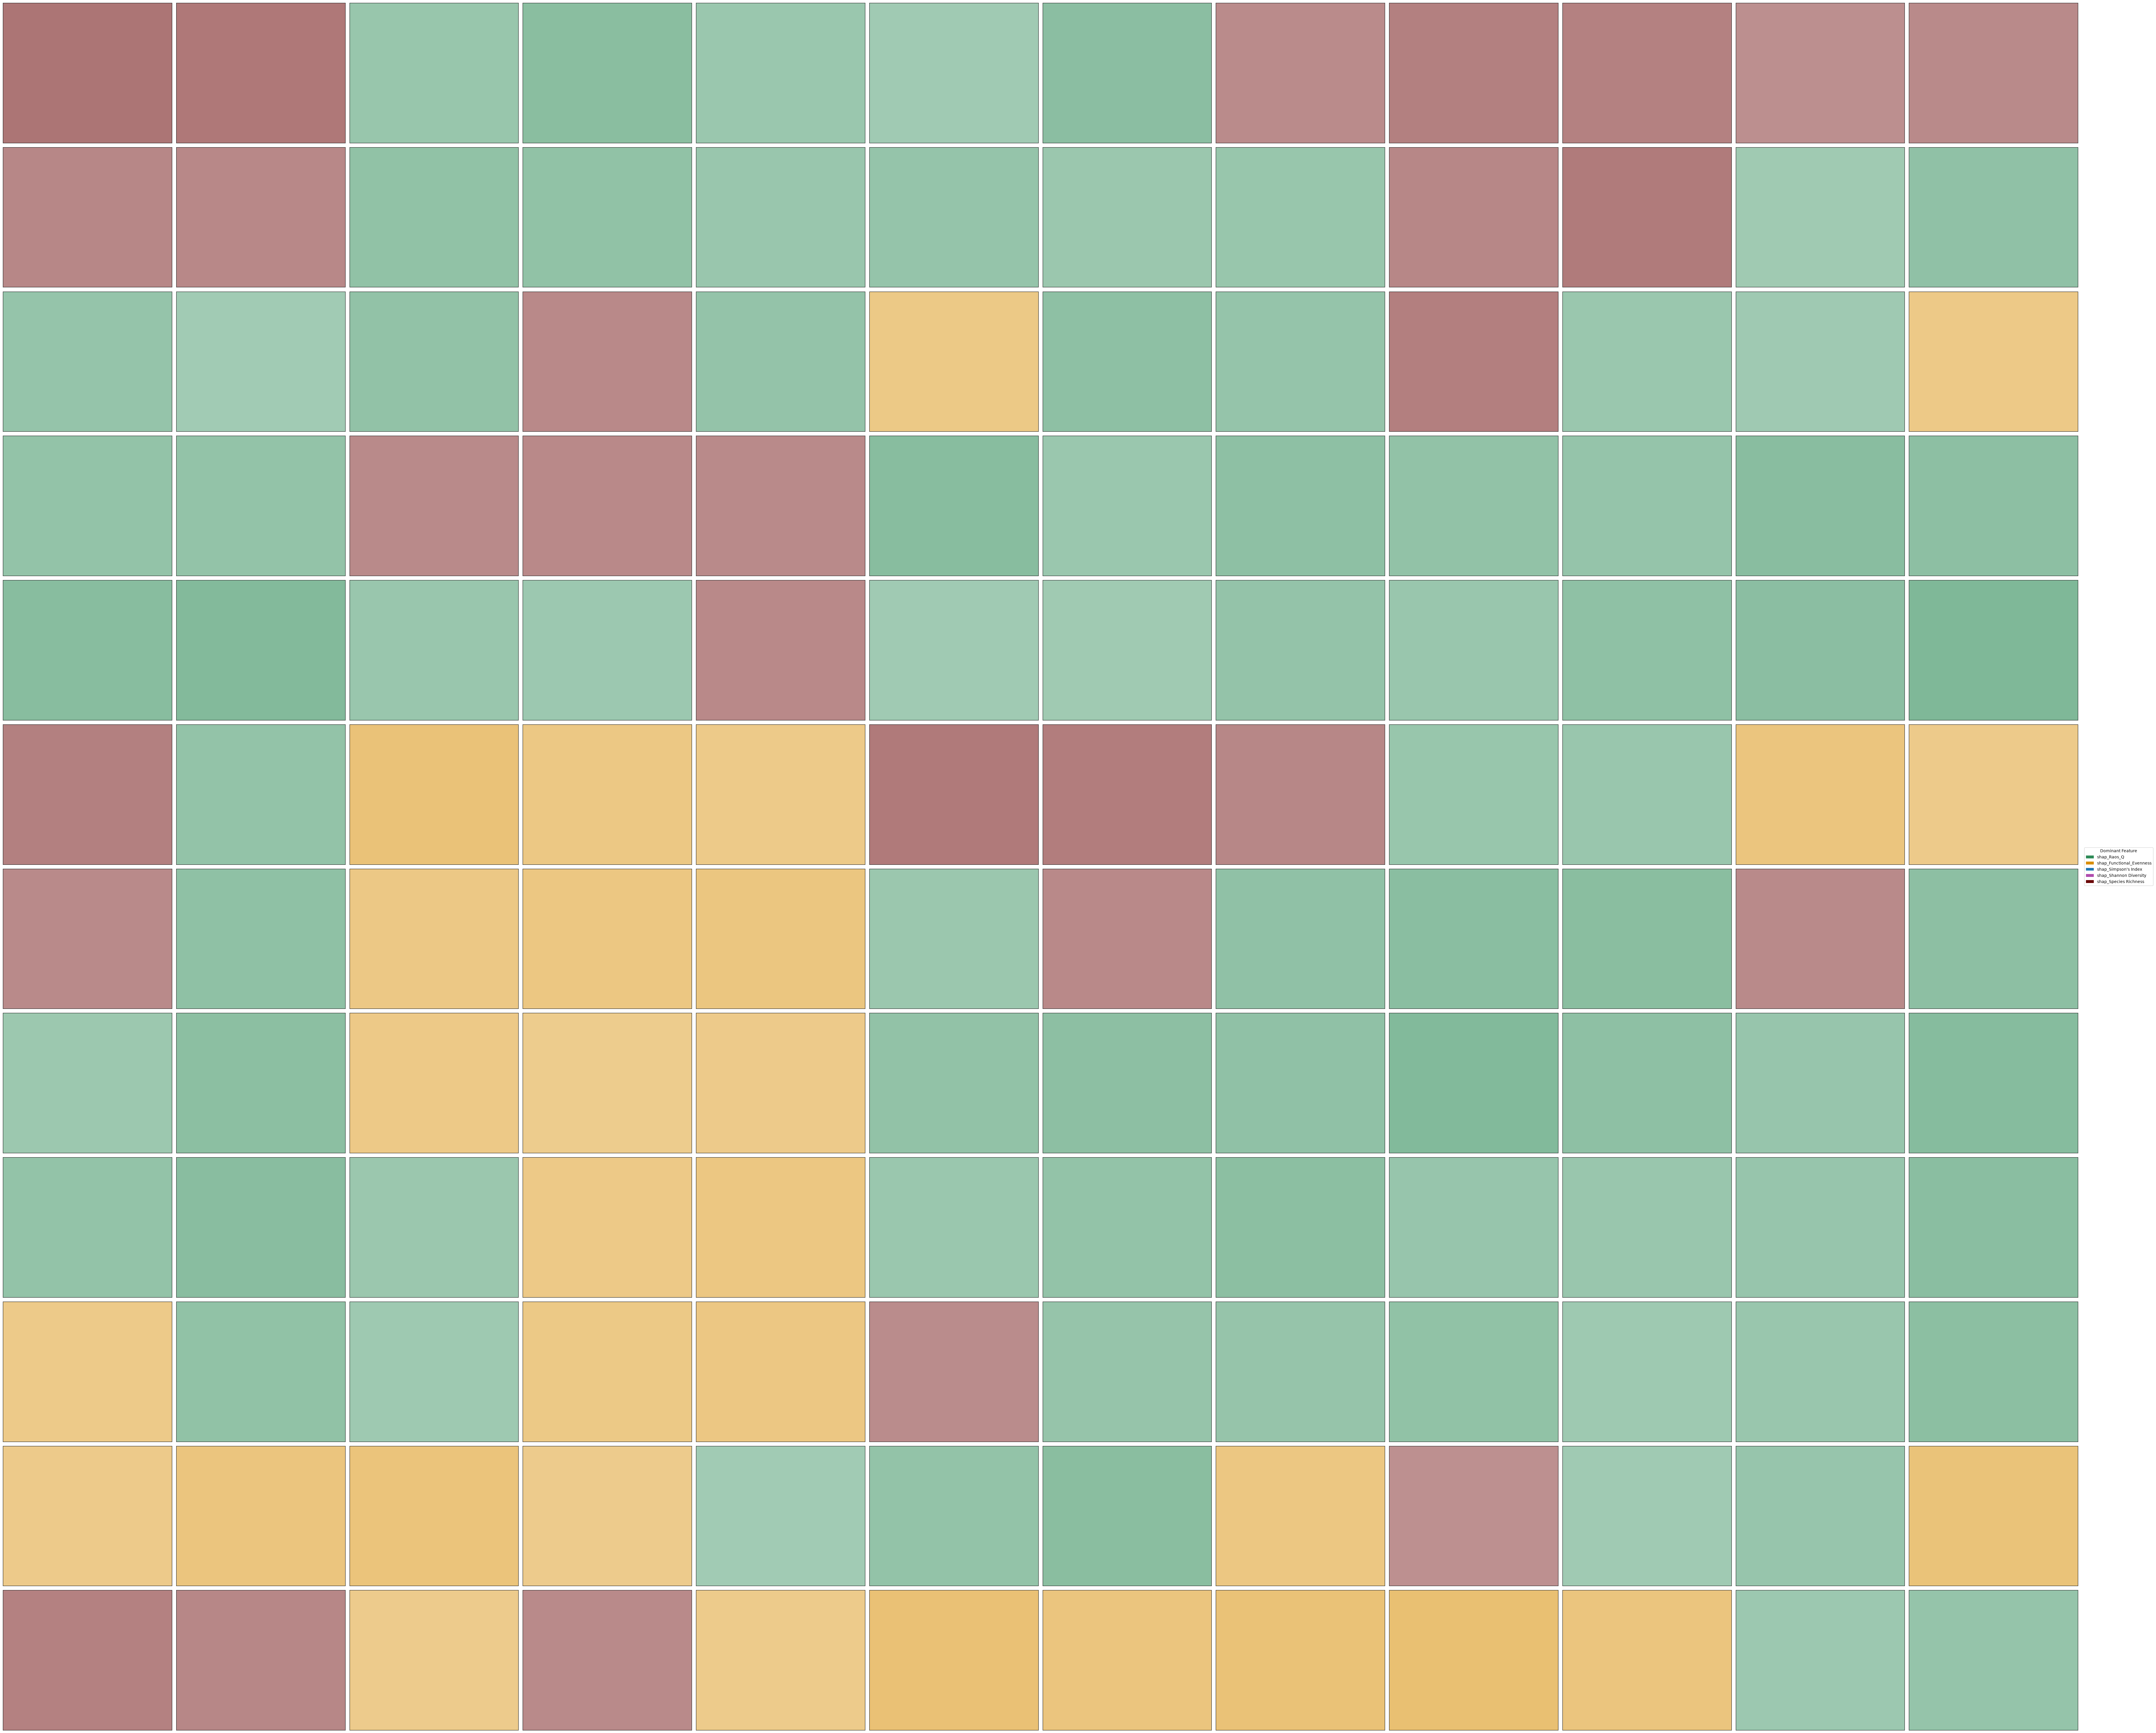

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import to_rgb

import pandas as pd
import itertools
import numpy as np

n_precip = 12
n_temp = 12

# --- Tertile splits for Temp and Precip (Low/Medium/High) ---
df2["Temp_group"] = pd.qcut(df2["Annual Temp"], q=n_temp, labels=np.arange(1, n_temp + 1))
df2["WSCI_group1"] = pd.qcut(df2["WSCI"], q=n_precip, labels=np.arange(1, n_precip + 1))

# --- Generate all combinations, Temp ordered High -> Low ---
temp_levels_ordered = np.arange(1, n_temp + 1)[::-1]
precip_levels_ordered = np.arange(1, n_precip + 1)

groups = {}
for temp_lvl, precip_lvl in itertools.product(temp_levels_ordered, precip_levels_ordered):
    name = f"Temp_{temp_lvl}_Precip_{precip_lvl}"
    groups[name] = df2[
        (df2["Temp_group"] == temp_lvl) &
        (df2["WSCI_group1"] == precip_lvl)
    ]

color_map = {
    "shap_Raos_Q": "#2E8B57",
    "shap_Functional_Evenness": "#D98E03",
    "shap_Simpson's Index": "#1F77B4",
    "shap_Shannon Diversity": "#B04CAE",
    "shap_Species Richness": "#6A0505",
}

# --- alpha settings ---
MIN_ALPHA = 0.15   # floor so low-dominance panels aren't invisible
MAX_ALPHA = 1.0

n = len(groups)
ncols = n_temp
nrows = n_precip

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()

for i, (name, df) in enumerate(groups.items()):
    ax = axes[i]

    if df.empty:
        ax.set_title(f"{name} (no data)")
        ax.axis('off')
        continue

    mode_feature = df['top_feature'].mode()
    if mode_feature.empty:
        ax.set_title(f"{name} (no data)")
        ax.axis('off')
        continue

    mode_feature = mode_feature.iloc[0]
    base_color = color_map.get(mode_feature, "#D3D3D3")

    n_matching = (df['top_feature'] == mode_feature).sum()
    dominance = n_matching / len(df)  # fraction between 0 and 1

    # scale dominance fraction into [MIN_ALPHA, MAX_ALPHA]
    alpha = MIN_ALPHA + dominance * (MAX_ALPHA - MIN_ALPHA)

    rgba = (*to_rgb(base_color), alpha)
    ax.set_facecolor(rgba)
    ax.set_xticks([])
    ax.set_yticks([])

# Hide unused axes
for j in range(n, len(axes)):
    axes[j].axis('off')

# Shared legend (kept at full opacity for legibility)
legend_elements = [Patch(facecolor=color, label=feat) for feat, color in color_map.items()]
fig.legend(
    handles=legend_elements,
    title="Dominant Feature",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5)
)

plt.tight_layout()
plt.show()

In [ ]:
df2.columns

Index(['PID', 'top_feature', 'WSCI_group', 'lon_x', 'lat_x', 'Raos_Q',
       'Functional_Evenness', 'Functional_Richness', 'Species Richness',
       'Shannon Diversity', 'Simpson's Index', 'WSCI', 'Annual Temp',
       'Annual Precipitation', 'Precipitation Seasonality', 'Soil Moisture',
       'SOC Content', 'Burnt Areas Probability', 'Elevation', 'Slope',
       'Depth to Bedrock', 'Northness', 'transformed npp', 'treecover2000',
       'pet_std', 'biome', 'lon_y', 'lat_y', 'Temp_group', 'WSCI_group1'],
      dtype='str')

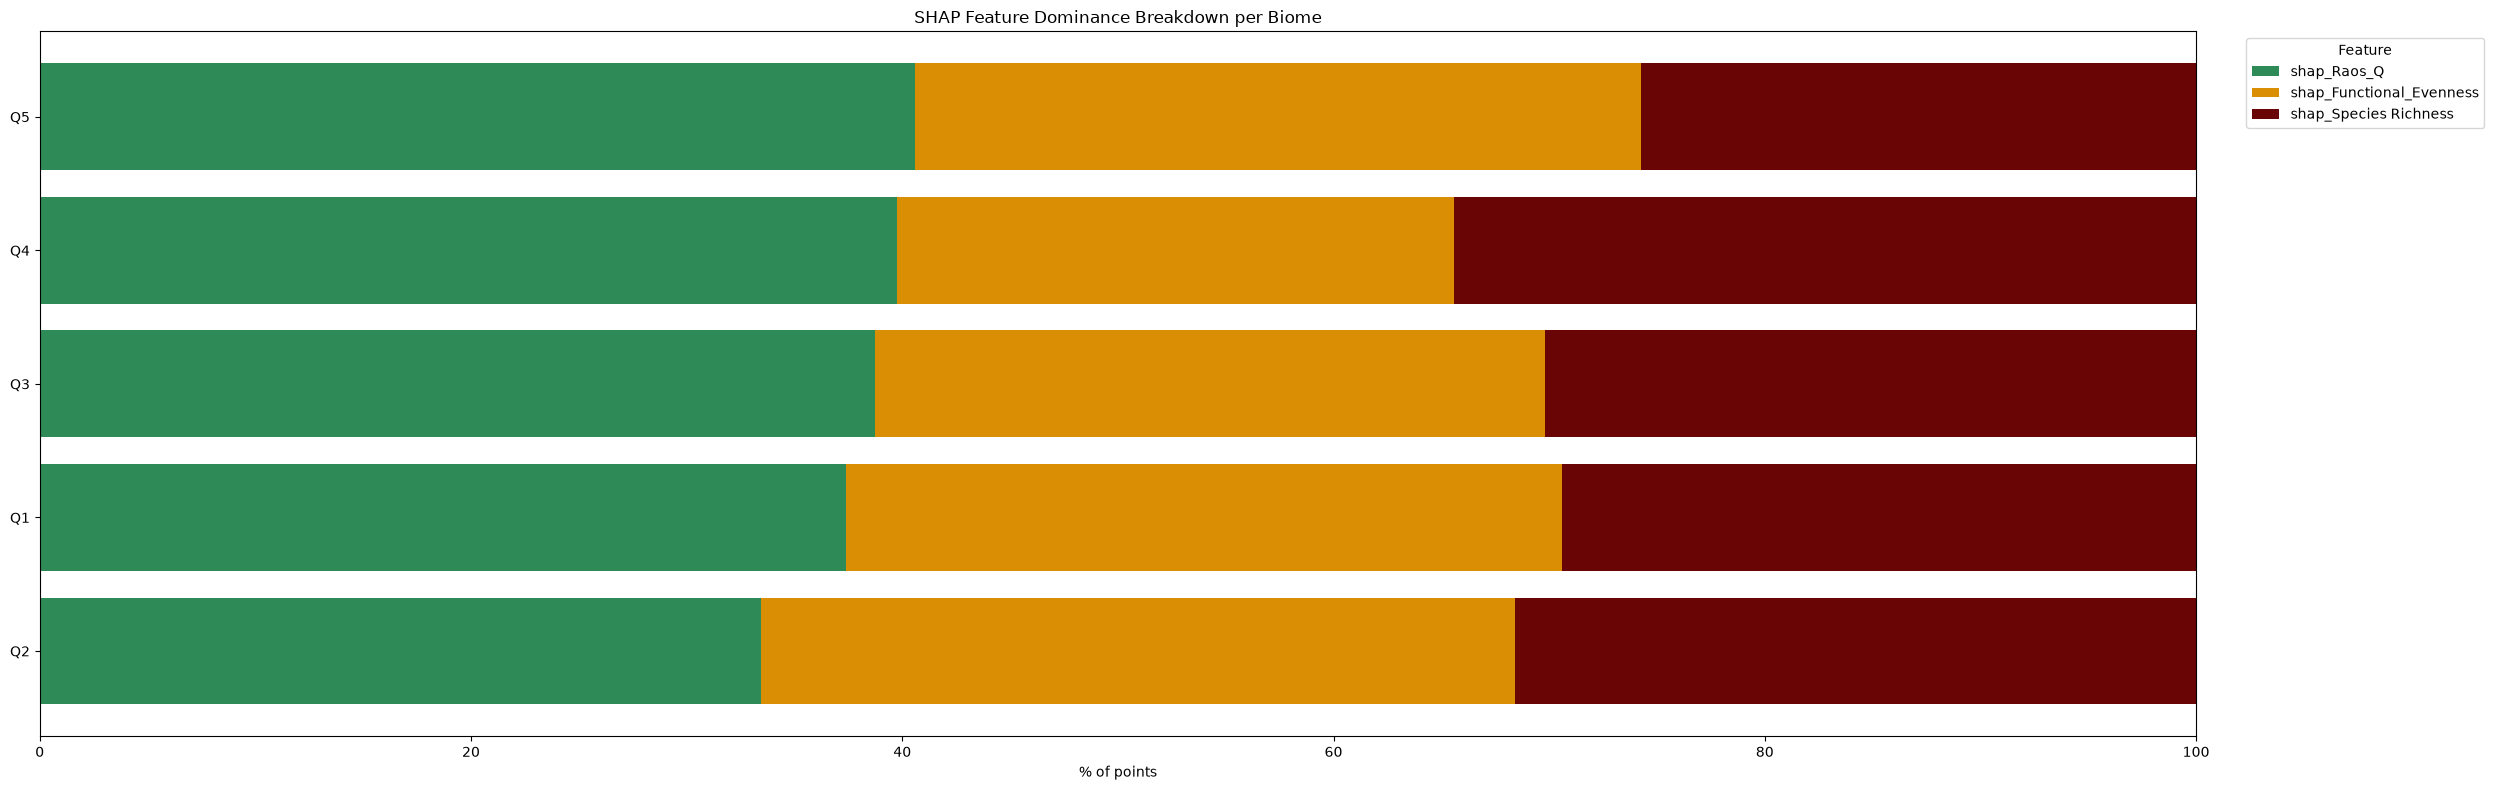

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import numpy as np

color_map = {
    "shap_Raos_Q": "#2E8B57",
    "shap_Functional_Evenness": "#D98E03",
    "shap_Simpson's Index": "#1F77B4",
    "shap_Shannon Diversity": "#B04CAE",
    "shap_Species Richness": "#6A0505",
}

# --- % of each feature within each biome ---
biome_feature_counts = (
    df2.groupby(['WSCI_group', 'top_feature'])
    .size()
    .reset_index(name='count')
)

biome_totals = df2.groupby('WSCI_group').size().reset_index(name='total')

biome_feature_counts = biome_feature_counts.merge(biome_totals, on='WSCI_group')
biome_feature_counts['pct'] = biome_feature_counts['count'] / biome_feature_counts['total'] * 100

# Pivot to wide format: rows = biome, columns = feature, values = pct
pivot = biome_feature_counts.pivot(index='WSCI_group', columns='top_feature', values='pct').fillna(0)

# Order columns consistently with color_map, keep only features present in data
features_ordered = [f for f in color_map.keys() if f in pivot.columns]
pivot = pivot[features_ordered]

# Optional: order biomes by their single most dominant feature's pct, descending
biome_order = pivot.max(axis=1).sort_values(ascending=False).index
pivot = pivot.loc[biome_order]

# --- Plot stacked horizontal bars ---
fig, ax = plt.subplots(figsize=(25,8))

left = np.zeros(len(pivot))
for feat in features_ordered:
    color = color_map.get(feat, "#D3D3D3")
    ax.barh(pivot.index, pivot[feat], left=left, color=color, label=feat)
    left += pivot[feat].values

ax.set_xlabel('% of points')
ax.set_title('SHAP Feature Dominance Breakdown per Biome')
ax.set_xlim(0, 100)
ax.invert_yaxis()

legend_elements = [Patch(facecolor=color_map[f], label=f) for f in features_ordered]
ax.legend(handles=legend_elements, title="Feature",
          bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

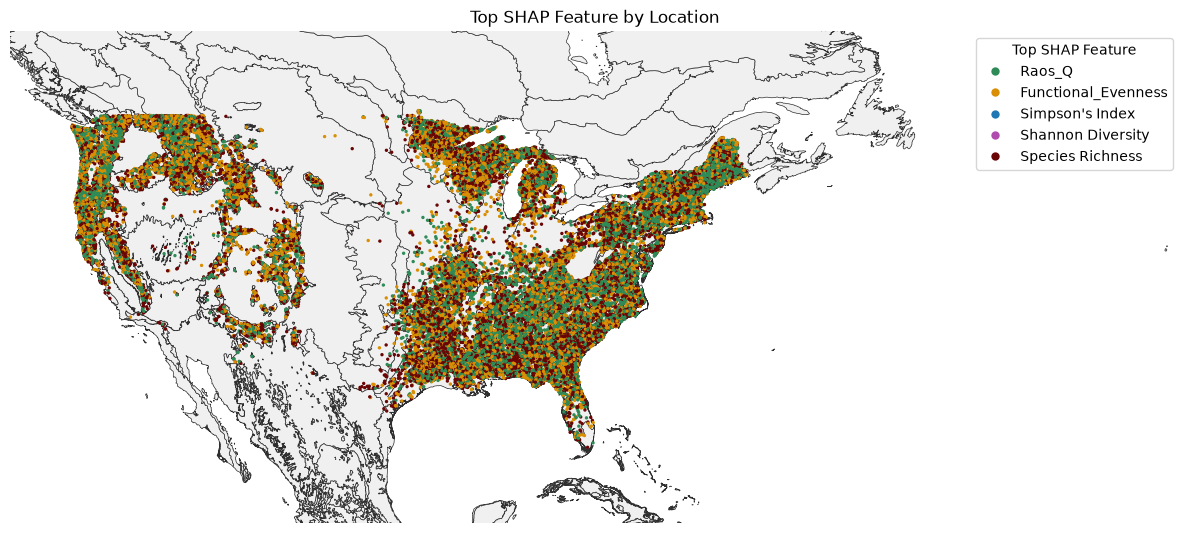

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

color_map = {
    "shap_Raos_Q": "#2E8B57",
    "shap_Functional_Evenness": "#D98E03",
    "shap_Simpson's Index": "#1F77B4",
    "shap_Shannon Diversity": "#B04CAE",
    "shap_Species Richness": "#6A0505",
}

# Convert to GeoDataFrame
top_feature_gdf = gpd.GeoDataFrame(
    top_feature_df,
    geometry=gpd.points_from_xy(top_feature_df['lon'], top_feature_df['lat']),
    crs="EPSG:4326"
)

# Map feature names to colours
top_feature_gdf["colour"] = top_feature_gdf["top_feature"].map(color_map)

# Load ecoregions
ecoregions = gpd.read_file("data/Ecoregions/Ecoregions2017.shp")

fig, ax = plt.subplots(figsize=(12, 12))

# Ecoregion background
ecoregions.plot(
    ax=ax,
    color="#f0f0f0",
    edgecolor="#2E2E2E",
    linewidth=0.5
)

# Plot points using your colours
top_feature_gdf.plot(
    ax=ax,
    color=top_feature_gdf["colour"],
    markersize=2
)

# Custom legend
legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor=colour,
        markeredgecolor='none',
        markersize=6,
        label=feature.replace("shap_", "")
    )
    for feature, colour in color_map.items()
]

ax.legend(
    handles=legend_handles,
    title="Top SHAP Feature",
    loc="upper right",
    frameon=True
)

ax.set_title("Top SHAP Feature by Location")
ax.set_axis_off()

# Zoom to North America
ax.set_xlim(-130, -30)
ax.set_ylim(20, 55)

plt.tight_layout()
plt.show()

In [ ]:
eco = pd.read_csv('data/lookup/PID_with_ecoregion.csv')
biome_df = fd_df[['PID', 'biome', 'transformed npp', 'lon', 'lat', 'WSCI']]

eco_df = pd.merge(df1, eco, on='PID', how='left')
eco = eco.merge(ecoregions, on='ECO_NAME', how='left')

biome_df = biome_df.merge(eco, on='PID', how='left')

shap_cols = ['shap_Raos_Q', 'shap_Functional_Evenness', 'shap_Species Richness']

biome_shap_df = biome_df.merge(eco_df[['PID'] + shap_cols], on='PID', how='left')

n_wsci_bins = 5
biome_shap_df['WSCI_group'] = pd.qcut(
    biome_shap_df['WSCI'],
    q=n_wsci_bins,
    labels=[f"WSCI_{i}" for i in range(1, n_wsci_bins + 1)]
)

# --- Mean SHAP values per ECO_NAME x WSCI group ---
group_shap_mean = (
    biome_shap_df
    .groupby(['ECO_NAME', 'WSCI_group'], observed=True)[shap_cols]
    .mean()
)
group_shap_mean = group_shap_mean.dropna()

group_shap_mean['dominant_feature'] = group_shap_mean[shap_cols].idxmax(axis=1)

# --- Plot counts per ECO_NAME x WSCI group (FIXED: match grouping keys) ---
plot_counts = (
    biome_shap_df
    .groupby(['ECO_NAME', 'WSCI_group'], observed=True)['PID']
    .nunique()
)
group_shap_mean['plot_count'] = plot_counts

# --- Filter to groups with enough plots ---
group_shap_mean = group_shap_mean[group_shap_mean['plot_count'] > 10]  # adjust threshold

group_shap_mean = group_shap_mean.reset_index()

In [ ]:
eco_df1 = pd.merge(
    group_shap_mean[['ECO_NAME', "WSCI_group", 'dominant_feature']].copy(),
    eco[['ECO_NAME', 'geometry']],
    on='ECO_NAME',
    how='left'
)

In [ ]:
sub_dfs = {
    wsci_grp: eco_df1[eco_df1['WSCI_group'] == wsci_grp].copy()
    for wsci_grp in eco_df1['WSCI_group'].unique()
}

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import geopandas as gpd
from shapely.geometry import box

# Load full ecoregion layer
ecoregions = gpd.read_file("data/Ecoregions/Ecoregions2017.shp")


for wsci_grp, df in sub_dfs.items():

    # GeoDataFrame containing only ecoregions with dominant features
    eco_map = df[['ECO_NAME', 'geometry', 'dominant_feature']].copy()
    eco_map = gpd.GeoDataFrame(eco_map, geometry="geometry")

    color_map = {
        "shap_Raos_Q": "#2E8B57",
        "shap_Functional_Evenness": "#D98E03",
        "shap_Species Richness": "#6A0505",
    }

    eco_map["color"] = eco_map["dominant_feature"].map(color_map)

    # Ensure same CRS
    if ecoregions.crs != eco_map.crs:
        eco_map = eco_map.to_crs(ecoregions.crs)


    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))

    # Background: ALL ecoregions
    ecoregions.plot(
        ax=ax,
        color="#f0f0f0",
        edgecolor="#545454",
        linewidth=0.2,
        zorder=1
    )

    # Overlay coloured ecoregions
    eco_map.plot(
        ax=ax,
        color=eco_map["color"],
        linewidth=0.2,
        zorder=2
    )

    # Legend
    legend_elements = [
        Patch(facecolor=color_map[k], edgecolor="black", label=k)
        for k in color_map
    ]

    ax.legend(
        handles=legend_elements,
        title="Dominant SHAP Feature",
        bbox_to_anchor=(1.3, 1),
        loc="upper right",
    )

    ax.set_title("Dominant SHAP Feature per Ecoregion")
    ax.set_axis_off()

    # North America extent
    ax.set_xlim(-160, -50)
    ax.set_ylim(20, 70)

    plt.tight_layout()
    plt.show()